# Notebook 1: EDA and Data Preparation
**Objective:** Explore the EcoCrop dataset, analyze correlations, handle categorical variables, and prepare the final training and testing sets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('ecocrop_cleaned_data (1).csv')

# 1. Exploration & Summary
print("--- Dataset Shape ---")
print(df.shape)
print("\n--- Summary Statistics ---")
display(df.describe())

# 2. Missing Values (Sanity Check)
print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Dataset Shape ---
(1479, 15)

--- Summary Statistics ---


,precipitation,hc_air_temperature,hc_relative_humidity,solar_radiation,wind_speed_sonic,Cereales (T),Maraichage (T),Legumineuses (T),Fourrages (T),Arboriculture (T),Olives (T),Cultures industrielles (T),Year
count,1479.000000,1479.000000,1479.000000,1479.000000,1479.000000,1.479000e+03,1479.000000,1479.000000,1.479000e+03,1479.000000,1479.000000,1479.000000,1479.000000
mean,1.870723,17.227515,72.319111,140.701833,2.078624,6.676370e+05,398707.170565,58229.699459,5.784223e+05,81725.594185,22597.494929,11075.117918,2022.104124
std,6.320202,4.558868,12.393049,77.320420,3.178549,1.077907e+06,256818.790001,92402.609024,4.099407e+05,146626.098147,24084.533615,13132.900336,1.763401
min,0.000000,5.191429,31.067273,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,2016.000000
25%,0.000000,15.589612,66.286453,91.625000,0.733333,7.500700e+04,234652.000000,2877.900000,1.287600e+05,0.000000,0.000000,833.000000,2022.000000
50%,0.000000,16.475190,66.286453,131.333333,0.800000,2.881050e+05,336396.000000,27300.000000,6.181500e+05,0.000000,21904.000000,8000.000000,2022.000000
75%,0.400000,17.234195,79.791458,181.958333,1.850000,4.988600e+05,632738.000000,44000.000000,1.054600e+06,29668.000000,34382.000000,15000.000000,2023.000000
max,90.200000,32.269583,99.917917,627.800000,15.779167,5.200000e+06,760133.841555,326330.000000,2.847120e+06,401031.000000,168000.000000,47844.000000,2024.000000



--- Missing Values ---
Governorate                   0
Date                          0
precipitation                 0
hc_air_temperature            0
hc_relative_humidity          0
solar_radiation               0
wind_speed_sonic              0
Cereales (T)                  0
Maraichage (T)                0
Legumineuses (T)              0
Fourrages (T)                 0
Arboriculture (T)             0
Olives (T)                    0
Cultures industrielles (T)    0
Year                          0
dtype: int64


## Visualizations & Correlation

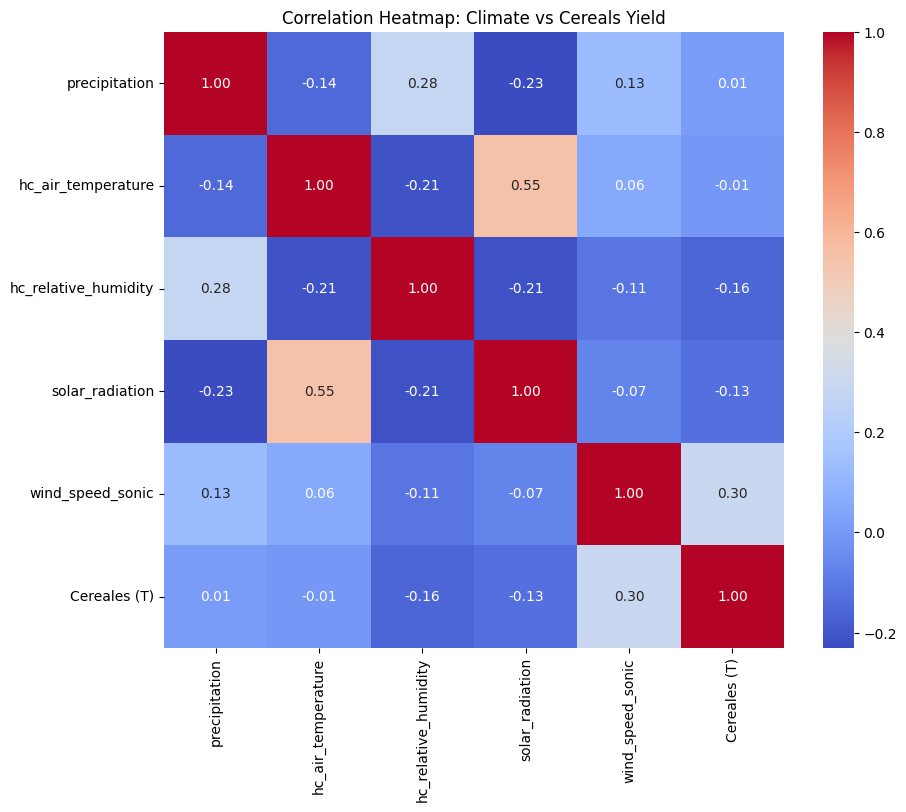

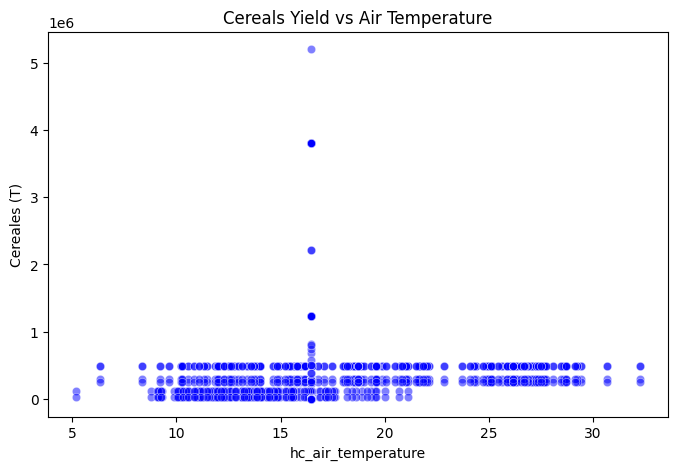

In [2]:
# 3. Features Relationships & Correlation
features = ['precipitation', 'hc_air_temperature', 'hc_relative_humidity',
            'solar_radiation', 'wind_speed_sonic', 'Cereales (T)']

plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Climate vs Cereals Yield')
plt.show()

# 4. Detailed EDA Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='hc_air_temperature', y='Cereales (T)', alpha=0.5, color='blue')
plt.title('Cereals Yield vs Air Temperature')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 5. Categorical Features Engineering
le = LabelEncoder()
df['Governorate_Encoded'] = le.fit_transform(df['Governorate'])

# 6. Define Features (X) and Target (y)
X_cols = ['precipitation', 'hc_air_temperature', 'hc_relative_humidity',
          'solar_radiation', 'wind_speed_sonic', 'Year', 'Governorate_Encoded']
target = 'Cereales (T)'

X = df[X_cols]
y = df[target]

# 7. Splitting data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_cols)

# 9. Save prepped data for Notebook 2
X_train_scaled.to_csv('X_train_prepped.csv', index=False)
X_test_scaled.to_csv('X_test_prepped.csv', index=False)
y_train.to_csv('y_train_prepped.csv', index=False)
y_test.to_csv('y_test_prepped.csv', index=False)

print("✅ Data successfully engineered, scaled, and saved for Notebook 2!")

✅ Data successfully engineered, scaled, and saved for Notebook 2!
